# Metropolis-Hastings Algorithms

Demonstrations of the independent and random-walk Metropolis-Hastings samplers implemented in `mcmc_algorithms.algorithms` (`independent_MH`, `random_walk_MH`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy import stats

from mcmc_algorithms.algorithms import independent_MH, random_walk_MH

FIGURES_DIR = Path("../figures")

## Independent MH: Normal proposal, Cauchy target

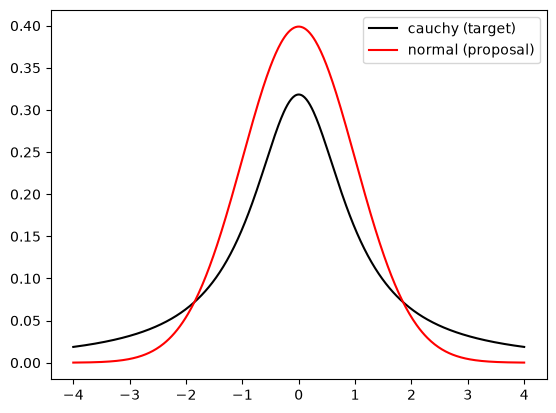

In [2]:
cauchy = stats.cauchy
normal = stats.norm
uniform = stats.uniform
student = stats.t

fig, ax = plt.subplots(1, 1)

x = np.linspace(-4, 4, 500)
ax.plot(x, cauchy.pdf(x), 'k', label="cauchy (target)")
ax.plot(x, normal.pdf(x), 'r', label="normal (proposal)")
plt.legend()
plt.show()

In [3]:
r = stats.norm()
pi_r_ratio = lambda x: cauchy.pdf(x) / normal.pdf(x)

accepted_xis = independent_MH(r, pi_r_ratio, steps=10000)

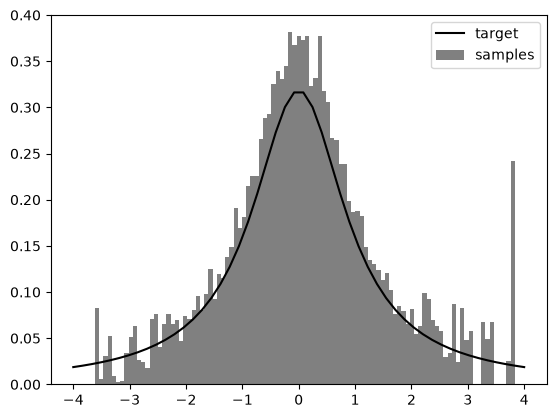

In [4]:
fig, ax_ = plt.subplots(1, 1)
x = np.linspace(-4, 4, 50)

plt.plot(x, cauchy.pdf(x), 'k', label='target')
plt.hist(accepted_xis, density=True, bins=100, label="samples", color='gray')
plt.legend()
fig.savefig(FIGURES_DIR / "mh_independent_cauchy.png", dpi=150, bbox_inches="tight")

## Independent MH: Uniform(-3, 3) proposal, Normal target

`r`'s density is constant over its support, so `pi(x) / r(x)` is proportional to `pi(x)` alone for any proposal the chain will ever see — using `normal.pdf` directly as the ratio is equivalent.

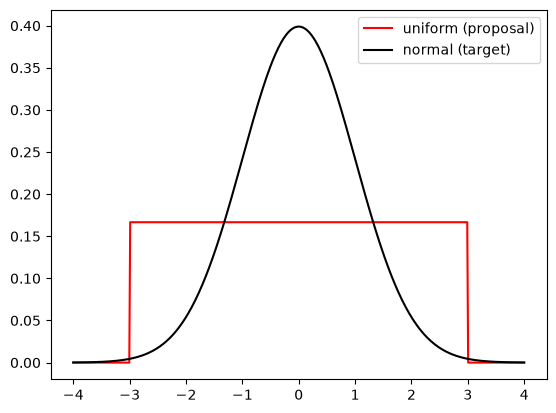

In [5]:
uniform = stats.uniform
normal = stats.norm

fig, ax = plt.subplots(1, 1)

x = np.linspace(-4, 4, 500)
ax.plot(x, uniform.pdf(x, loc=-3, scale=6), 'r', label="uniform (proposal)")
ax.plot(x, normal.pdf(x), 'k', label="normal (target)")
plt.legend()

In [6]:
r = stats.uniform(loc=-3, scale=6)
pi_r_ratio = normal.pdf

accepted_xis = independent_MH(r, pi_r_ratio, steps=50000)

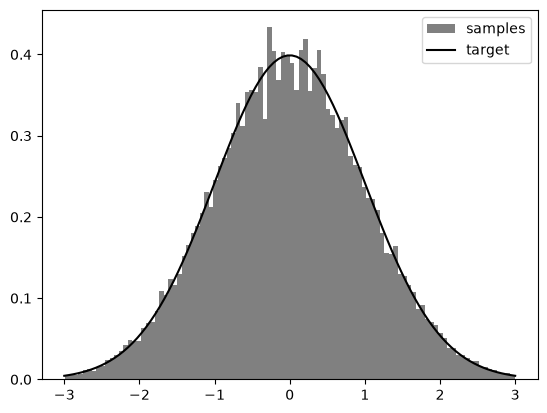

In [7]:
fig, ax_ = plt.subplots(1, 1)
x = np.linspace(-3, 3, 100)
plt.hist(accepted_xis, density=True, bins=100, label="samples", color='gray')
plt.plot(x, normal.pdf(x), 'k-', label='target')
plt.legend()

## Random-Walk MH: Normal random walk, Student-t(df=1) target

In [8]:
df = 1
pi = lambda x: student.pdf(x, df)

accepted_xis = random_walk_MH(stats.norm, pi, var=1, steps=10000)

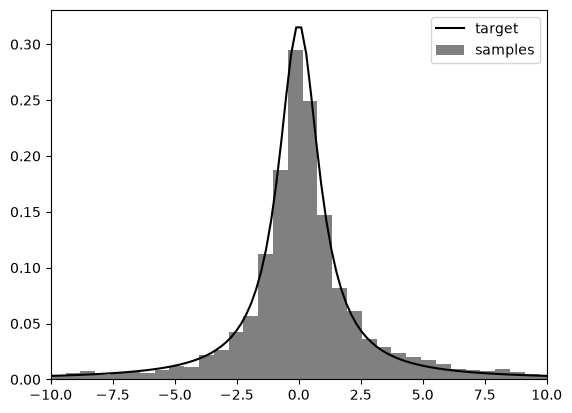

In [9]:
fig, ax_ = plt.subplots(1, 1)
x = np.linspace(-10, 10, 100)

plt.plot(x, student.pdf(x, df), 'k-', label='target')
plt.hist(accepted_xis, density=True, bins=100, label="samples", color='gray')
plt.xlim(-10, 10)
plt.legend()

## Random-Walk MH: bimodal normal-mixture target

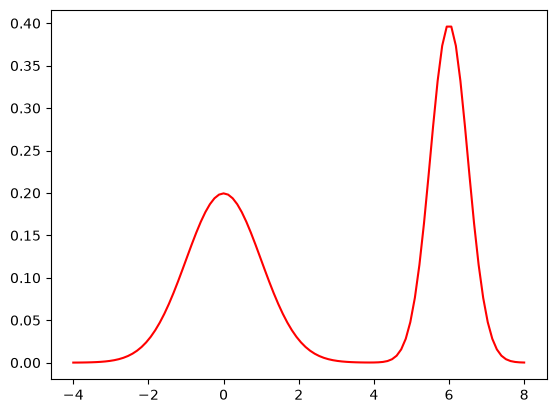

In [10]:
def bimodal_normal(x):
    return 1 / 2 * (normal.pdf(x, 0, 1) + normal.pdf(x, 6, 0.5))


x = np.linspace(-4, 8, 100)
plt.plot(x, bimodal_normal(x), 'r-')

In [11]:
accepted_xis = random_walk_MH(stats.norm, bimodal_normal, var=5, steps=20000)

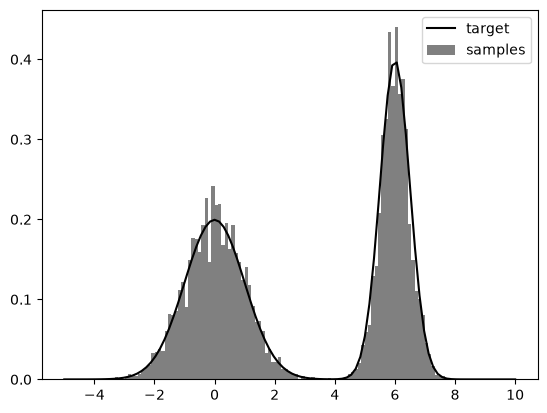

In [12]:
fig, ax_ = plt.subplots(1, 1)
x = np.linspace(-5, 10, 100)

plt.plot(x, bimodal_normal(x), 'k-', label='target')
plt.hist(accepted_xis, density=True, bins=100, label="samples", color='gray')
plt.legend()
fig.savefig(FIGURES_DIR / "mh_random_walk_bimodal.png", dpi=150, bbox_inches="tight")

## Illustration: a rejected proposal in a random walk

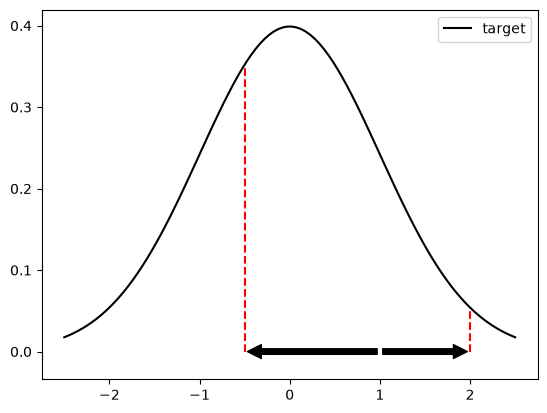

In [13]:
fig, ax = plt.subplots(1, 1)
x = np.linspace(-2.5, 2.5, 100)
ax.plot(x, normal.pdf(x), 'k-', label="target")
ax.plot((2, 2), (0, normal.pdf(2)), 'r--')
ax.plot((-0.5, -0.5), (0, normal.pdf(-0.5)), 'r--')
arrow_1 = mpatches.FancyArrowPatch((1, 0), (2, 0), mutation_scale=20, color='k')
arrow_2 = mpatches.FancyArrowPatch((1, 0), (-0.5, 0), mutation_scale=20, color='k')
ax.add_patch(arrow_1)
ax.add_patch(arrow_2)
plt.legend()